### Detecção de fraudes em transações bancárias

**Aluna:** Marina dos Santos Silva

<a href="https://www.linkedin.com/in//marina-silva11835561799/">
  <img src="https://cdn-icons-png.flaticon.com/512/174/174857.png" alt="LinkedIn Logo" width="50">
</a>

 <a href="https://github.com/seu-usuario/MarinaSSilva">
  <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub Logo" width="50">
</a>

In [17]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head(10)  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


#### Problema de classificação desbalanceada

###### Fraudes são raras → modelo pode ignorar a classe 1.


In [18]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

#### Feature Engineering

###### Criamos variáveis que ajudam o modelo


In [19]:
import numpy as np
df["Amount_log"] = np.log1p(df["Amount"])

In [ ]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])

In [22]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
 )

#### Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pres = model.predict(x_test)

C:\Users\Marina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pres))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.69      0.77       148

    accuracy                           1.00     85443
   macro avg       0.94      0.84      0.88     85443
weighted avg       1.00      1.00      1.00     85443



Acuray pode ser alta mesmno sem detectar fraudes.
Por isso usamos:
- Recall (mais importante) 
- Precision 
- F1-Score 

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------------- ------------- 6.3/9.3 MB 33.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 35.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 47.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 55.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----

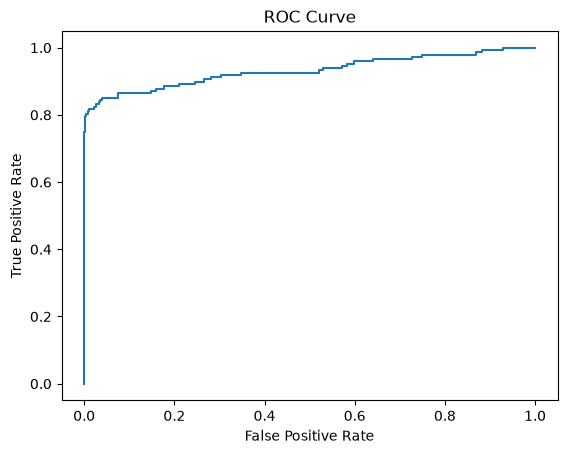

AUC: 0.9317510135729258


In [28]:
!pip install matplotlib
from sklearn.metrics import roc_curve, roc_auc_score  # ← CORRIGIDO!
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

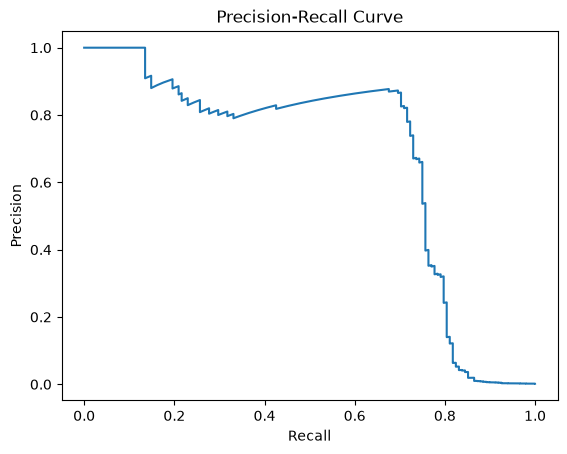

In [29]:
from sklearn.metrics import precision_recall_curve

preision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, preision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#### Balanceamento de dados

In [30]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [34]:
# Oversampling
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(x, y)

Defaulting to user installation because normal site-packages is not writeable


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Criar o modelo com parâmetros simples
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Treinar
rf.fit(x_train, y_train)

# Prever
y_pred_rf = rf.predict(x_test)

# Avaliar
print("Relatório do Random Forest:")
print(classification_report(y_test, y_pred_rf))

Relatório do Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [38]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pres=d = pipeline.predict(x_test)

In [39]:
threshold = 0.3

y_pred_custom = (y_probs >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.72      0.76       148

    accuracy                           1.00     85443
   macro avg       0.91      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [42]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.6/69.5 MB 18.1 MB/s eta 0:00:04
   ------ --------------------------------- 11.8/69.5 MB 33.8 MB/s eta 0:00:02
   ------------- -------------------------- 23.6/69.5 MB 42.6 MB/s eta 0:00:02
   -------------------- ------------------- 35.1/69.5 MB 46.0 MB/s eta 0:00:01
   --------------------------- ------------ 47.7/69.5 MB 49.3 MB/s eta 0:00:01
   ------------------------------------- -- 64.7/69.5 MB 55.2 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 52.6 MB/s  0:00:01


C:\Users\Marina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [23:23:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [43]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



#### Importância das variáveis

###### Ajuda a entender quais variáveis influenciammais o modelo

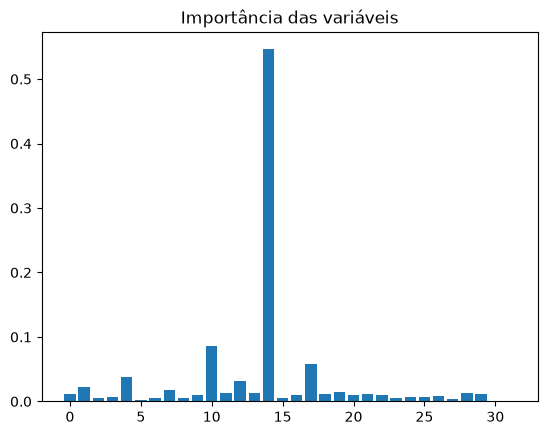

In [44]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

#### Ajuste de hiperârametros

###### Testamos várias combinações para melhorar o modelo

In [49]:
# Ajuste de hiperparâmetros
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Definir os parâmetros para testar
param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

# Criar o GridSearch
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1
)

# Treinar
grid.fit(x_train, y_train)

# Resultados
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)

Melhores parâmetros: {'max_depth': 5, 'n_estimators': 100}
Melhor score: 0.014619883040935672


#### Explicabiidade (SHAP)

###### SHAP mostra como cada variável influencia a decisão do modelo.

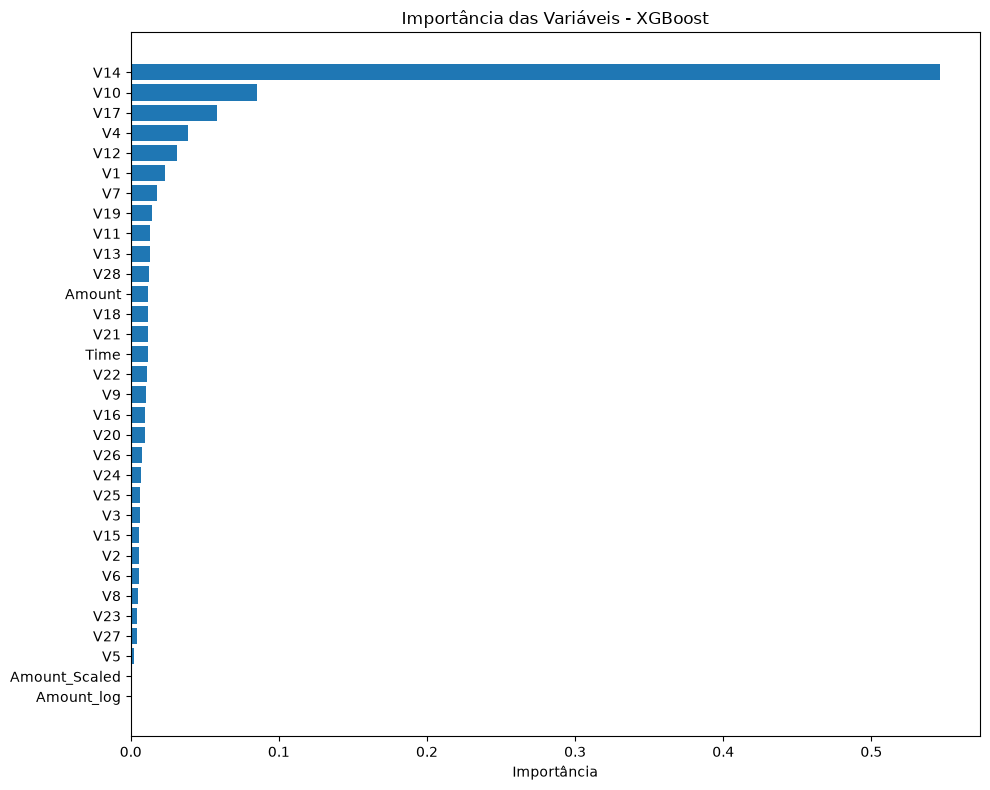

Top 10 variáveis mais importantes:
   feature  importance
13     V13    0.013027
11     V11    0.013059
19     V19    0.014059
7       V7    0.018019
1       V1    0.022839
12     V12    0.030967
4       V4    0.038334
17     V17    0.058477
10     V10    0.085584
14     V14    0.546044


In [56]:
# Importância das variáveis (não precisa de SHAP)
import matplotlib.pyplot as plt
import pandas as pd

# Pegar importância do XGBoost
importancia = pd.DataFrame({
    'feature': x_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

# Plotar
plt.figure(figsize=(10, 8))
plt.barh(importancia['feature'], importancia['importance'])
plt.xlabel('Importância')
plt.title('Importância das Variáveis - XGBoost')
plt.tight_layout()
plt.show()

# Mostrar top 10
print("Top 10 variáveis mais importantes:")
print(importancia.tail(10))